# Гипотезы, статистический анализ и симуляция A/B-теста

## Цель анализа

Цель ноутбука — проверить несколько продуктовых гипотез о факторах, связанных с клиентским опытом на маркетплейсе Olist, и продемонстрировать понимание логики проектирования и анализа A/B-тестов.

Анализ состоит из двух частей:

1. **Наблюдательный статистический анализ** — сравнение характеристик существующих групп заказов, сформированных историческими данными.
2. **Симуляция A/B-теста** — искусственно созданный эксперимент для демонстрации расчёта эффекта, статистической значимости и доверительного интервала.

## Методологическое ограничение

Проверяемые на исторических данных зависимости не являются результатами A/B-теста. Заказы не распределялись случайным образом между группами, поэтому статистически значимая связь не доказывает причинно-следственный эффект.

Например, задержка доставки может быть связана не только с отзывом, но и с категорией товара, регионом клиента, продавцом, стоимостью заказа или сложностью логистики.

Поэтому результаты наблюдательного анализа используются для:

* выявления потенциальных проблемных факторов;
* оценки размера различий между группами;
* формирования продуктовых гипотез;
* подготовки дизайна будущего контролируемого эксперимента.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
orders_base = pd.read_csv(
    "../data/processed/orders_base.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

orders_base.shape

(99441, 33)

In [3]:
orders_base.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'items_count',
 'products_count',
 'sellers_count',
 'product_revenue',
 'freight_value',
 'payment_value',
 'payment_installments',
 'payment_types_count',
 'payment_records_count',
 'review_score',
 'review_records_count',
 'first_review_creation_date',
 'last_review_answer_timestamp',
 'gmv',
 'order_value_with_freight',
 'delivery_days',
 'delivery_delay_days',
 'is_delivered',
 'has_review',
 'has_payment',
 'has_items']

## 1. Подготовка аналитической выборки

Для анализа клиентской оценки используются только заказы, которые:

* были доставлены клиенту;
* имеют оценку отзыва;
* имеют рассчитанные сроки фактической доставки и отклонения от обещанной даты.

Такое ограничение необходимо, поскольку оценивать влияние задержки доставки можно только для завершённых заказов с известным клиентским отзывом.

Негативный клиентский опыт определяется как:

* `bad_review = 1`, если `review_score <= 3`;
* `bad_review = 0`, если `review_score >= 4`.

Задержанным считается заказ, доставленный позже обещанной даты:

* `is_delayed = 1`, если `delivery_delay_days > 0`;
* `is_delayed = 0`, если заказ доставлен вовремя или раньше срока.


In [4]:
analysis_df = orders_base.loc[
    (orders_base["is_delivered"] == 1)
    & (orders_base["has_review"] == 1)
    & orders_base["review_score"].notna()
    & orders_base["delivery_days"].notna()
    & orders_base["delivery_delay_days"].notna()
].copy()

analysis_df["bad_review"] = (
    analysis_df["review_score"] <= 3
).astype(int)

analysis_df["is_delayed"] = (
    analysis_df["delivery_delay_days"] > 0
).astype(int)

analysis_df.shape

(95824, 35)

In [5]:
analysis_df.groupby("is_delayed").agg(
    orders=("order_id", "nunique"),
    average_review_score=("review_score", "mean"),
    bad_review_rate=("bad_review", "mean"),
    average_delivery_days=("delivery_days", "mean"),
    average_delay_days=("delivery_delay_days", "mean"),
)

,orders,average_review_score,bad_review_rate,average_delivery_days,average_delay_days
is_delayed,,,,,
0,89443,4.290589,0.173373,10.531981,-13.513366
1,6381,2.271823,0.732487,33.362326,10.518414


## 2. Гипотеза 1: задержка доставки и клиентская оценка

### Бизнес-гипотеза

Заказы, доставленные позже обещанной даты, связаны с более низкой клиентской оценкой и более высокой вероятностью негативного отзыва.

Для проверки рассматриваются две метрики:

* средний `review_score`;
* доля негативных отзывов `bad_review_rate`.

### Статистические гипотезы

Для оценки отзыва:

* **H₀:** распределение `review_score` не различается между задержанными и доставленными вовремя заказами;
* **H₁:** распределение `review_score` различается между группами.

Для доли негативных отзывов:

* **H₀:** `bad_review_rate` одинаков в двух группах;
* **H₁:** `bad_review_rate` различается между группами.

Для `review_score` используется критерий Манна — Уитни, поскольку оценка принимает только пять дискретных значений и не обязательно соответствует нормальному распределению.

Для бинарной метрики `bad_review` используется тест разности двух долей. Помимо p-value рассчитываются:

* абсолютная разница долей;
* относительный риск;
* 95%-й доверительный интервал абсолютной разницы.

При интерпретации основной акцент делается на размере эффекта, поскольку при большой выборке статистически значимыми могут оказаться даже небольшие различия.


In [6]:
from scipy.stats import mannwhitneyu, norm

on_time = analysis_df.loc[analysis_df["is_delayed"] == 0]
delayed = analysis_df.loc[analysis_df["is_delayed"] == 1]

# Критерий Манна — Уитни для review_score
u_statistic, review_p_value = mannwhitneyu(
    delayed["review_score"],
    on_time["review_score"],
    alternative="two-sided",
)

# Параметры для сравнения долей плохих отзывов
delayed_bad_rate = delayed["bad_review"].mean()
on_time_bad_rate = on_time["bad_review"].mean()

n_delayed = len(delayed)
n_on_time = len(on_time)

delayed_bad_count = delayed["bad_review"].sum()
on_time_bad_count = on_time["bad_review"].sum()

absolute_effect = delayed_bad_rate - on_time_bad_rate
relative_risk = delayed_bad_rate / on_time_bad_rate

# Z-тест равенства двух долей
pooled_rate = (
    delayed_bad_count + on_time_bad_count
) / (
    n_delayed + n_on_time
)

pooled_se = np.sqrt(
    pooled_rate
    * (1 - pooled_rate)
    * (1 / n_delayed + 1 / n_on_time)
)

z_statistic = absolute_effect / pooled_se
bad_review_p_value = 2 * norm.sf(abs(z_statistic))

# 95%-й доверительный интервал разницы долей
effect_se = np.sqrt(
    delayed_bad_rate * (1 - delayed_bad_rate) / n_delayed
    + on_time_bad_rate * (1 - on_time_bad_rate) / n_on_time
)

critical_value = norm.ppf(0.975)

ci_lower = absolute_effect - critical_value * effect_se
ci_upper = absolute_effect + critical_value * effect_se

hypothesis_1_results = pd.Series({
    "delayed_orders": n_delayed,
    "on_time_orders": n_on_time,
    "delayed_avg_review": delayed["review_score"].mean(),
    "on_time_avg_review": on_time["review_score"].mean(),
    "review_score_difference": (
        delayed["review_score"].mean()
        - on_time["review_score"].mean()
    ),
    "mann_whitney_p_value": review_p_value,
    "delayed_bad_review_rate": delayed_bad_rate,
    "on_time_bad_review_rate": on_time_bad_rate,
    "absolute_effect": absolute_effect,
    "relative_risk": relative_risk,
    "z_statistic": z_statistic,
    "bad_review_p_value": bad_review_p_value,
    "ci_95_lower": ci_lower,
    "ci_95_upper": ci_upper,
})

hypothesis_1_results

delayed_orders              6381.000000
on_time_orders             89443.000000
delayed_avg_review             2.271823
on_time_avg_review             4.290589
review_score_difference       -2.018767
mann_whitney_p_value           0.000000
delayed_bad_review_rate        0.732487
on_time_bad_review_rate        0.173373
absolute_effect                0.559114
relative_risk                  4.224920
z_statistic                  105.827715
bad_review_p_value             0.000000
ci_95_lower                    0.547973
ci_95_upper                    0.570255
dtype: float64

### Результаты проверки гипотезы

В анализ вошло:

* 89 443 заказа, доставленных вовремя или раньше обещанной даты;
* 6 381 задержанный заказ.

Средняя оценка составила:

* **4,29** у заказов без задержки;
* **2,27** у задержанных заказов.

Разница равна **−2,02 балла**.

Критерий Манна — Уитни показал статистически значимое различие распределений оценок между группами (`p-value < 0,001`). Нулевая гипотеза об отсутствии различий отвергается.

Доля негативных отзывов составила:

* **17,34%** у заказов без задержки;
* **73,25%** у задержанных заказов.

Абсолютная разница равна **55,91 процентного пункта**.
95%-й доверительный интервал разницы составляет **[54,80; 57,03] процентного пункта**.

Относительный риск негативного отзыва у задержанного заказа примерно в **4,22 раза выше**, чем у заказа, доставленного вовремя.

### Бизнес-интерпретация

Задержка относительно обещанной даты является одним из наиболее сильных операционных сигналов ухудшения клиентского опыта в данных Olist.

Различие имеет не только статистическую, но и существенную практическую значимость: почти три четверти задержанных заказов получают оценку не выше трёх.

Это подтверждает целесообразность следующих продуктовых и операционных решений:

* мониторинг заказов, приближающихся к обещанной дате;
* раннее предупреждение клиента о возможной задержке;
* приоритизация задержанных заказов службой поддержки;
* анализ продавцов, категорий и регионов с повышенной частотой просрочек;
* отдельные сценарии компенсации для критически задержанных заказов.

### Ограничение интерпретации

Полученный результат не доказывает, что задержка сама по себе является единственной причиной негативного отзыва.

Задержанные заказы могут отличаться по регионам, категориям товаров, продавцам, стоимости, количеству товарных позиций и сложности логистики. Поэтому результат следует интерпретировать как сильную наблюдательную связь и основание для будущего контролируемого эксперимента, а не как причинный эффект.


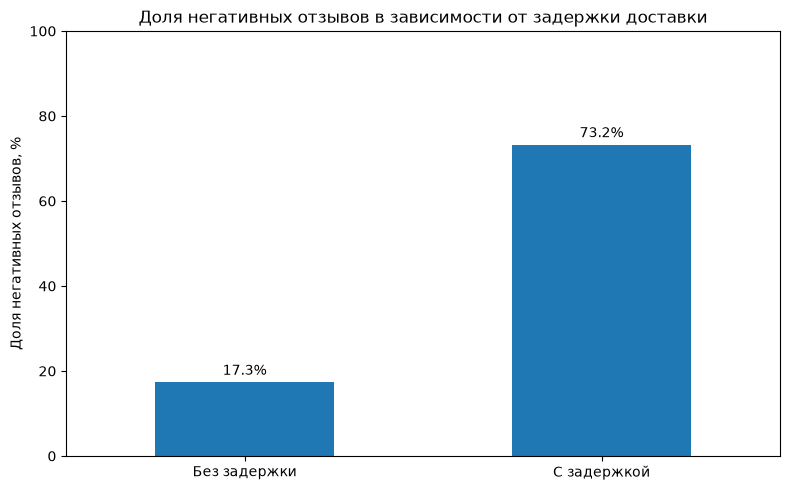

In [7]:
delay_comparison = (
    analysis_df.groupby("is_delayed")
    .agg(
        average_review_score=("review_score", "mean"),
        bad_review_rate=("bad_review", "mean"),
    )
    .rename(index={0: "Без задержки", 1: "С задержкой"})
)

ax = (delay_comparison["bad_review_rate"] * 100).plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Доля негативных отзывов в зависимости от задержки доставки")
ax.set_xlabel("")
ax.set_ylabel("Доля негативных отзывов, %")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

In [8]:
ax.set_title("Доля негативных отзывов: заказы с задержкой и без задержки")

Text(0.5, 1.0, 'Доля негативных отзывов: заказы с задержкой и без задержки')

## 3. Гипотеза 2: количество продавцов и риск негативного отзыва

### Бизнес-гипотеза

Заказы, включающие товары нескольких продавцов, связаны с более высокой долей негативных отзывов по сравнению с заказами одного продавца.

Возможное объяснение состоит в том, что multi-seller заказ сложнее с точки зрения исполнения:

- товары могут отправляться разными посылками;
- отдельные части заказа могут доставляться в разные сроки;
- возрастает риск задержки или неполной доставки;
- клиент может воспринимать проблемы одной части заказа как проблему всего заказа.

Для первичного анализа заказы разделяются на две группы:

- один продавец: `sellers_count == 1`;
- несколько продавцов: `sellers_count > 1`.

Поскольку данные являются наблюдательными, обнаруженная связь не будет доказывать, что именно количество продавцов стало причиной негативного отзыва.

In [9]:
analysis_df["is_multi_seller"] = (
    analysis_df["sellers_count"] > 1
).astype(int)

multi_seller_summary = (
    analysis_df.groupby("is_multi_seller")
    .agg(
        orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean"),
        bad_review_rate=("bad_review", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        delayed_order_rate=("is_delayed", "mean"),
        average_items_count=("items_count", "mean"),
    )
    .rename(index={
        0: "Один продавец",
        1: "Несколько продавцов",
    })
)

multi_seller_summary

,orders,average_review_score,bad_review_rate,average_delivery_days,delayed_order_rate,average_items_count
is_multi_seller,,,,,,
Один продавец,94563,4.173521,0.205334,12.097702,0.067352,1.124087
Несколько продавцов,1261,2.854084,0.605868,8.645519,0.009516,2.430611


In [10]:
ax.set_title("Доля негативных отзывов: заказы с задержкой и без задержки");

In [11]:
analysis_df["sellers_count"].value_counts(dropna=False).sort_index()

sellers_count
1.0    94563
2.0     1202
3.0       54
4.0        3
5.0        2
Name: count, dtype: int64

In [12]:
analysis_df.loc[
    analysis_df["sellers_count"] < 1,
    [
        "order_id",
        "order_status",
        "has_items",
        "items_count",
        "sellers_count",
        "review_score",
    ],
].head(10)

,order_id,order_status,has_items,items_count,sellers_count,review_score


In [13]:
seller_analysis_df = analysis_df.loc[
    (analysis_df["has_items"] == 1)
    & (analysis_df["sellers_count"] >= 1)
].copy()

seller_analysis_df["seller_group"] = np.where(
    seller_analysis_df["sellers_count"] == 1,
    "Один продавец",
    "Несколько продавцов",
)

multi_seller_summary = (
    seller_analysis_df.groupby("seller_group")
    .agg(
        orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean"),
        bad_review_rate=("bad_review", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        delayed_order_rate=("is_delayed", "mean"),
        average_items_count=("items_count", "mean"),
        average_products_count=("products_count", "mean"),
        average_freight_value=("freight_value", "mean"),
    )
)

multi_seller_summary

,orders,average_review_score,bad_review_rate,average_delivery_days,delayed_order_rate,average_items_count,average_products_count,average_freight_value
seller_group,,,,,,,,
Несколько продавцов,1261,2.854084,0.605868,8.645519,0.009516,2.430611,2.176051,46.657827
Один продавец,94563,4.173521,0.205334,12.097702,0.067352,1.124087,1.023138,22.444237


### Проверка статистической значимости

Основной метрикой является доля негативных отзывов.

Для неё проверяются гипотезы:

- **H₀:** доля негативных отзывов одинакова у заказов одного и нескольких продавцов;
- **H₁:** доли негативных отзывов различаются.

Дополнительно проводится анализ только среди заказов без задержки доставки. Это позволяет проверить, сохраняется ли связь между количеством продавцов и негативным отзывом после исключения явного эффекта просрочки.

Такой анализ не устраняет все возможные смешивающие факторы, но служит проверкой устойчивости результата.

In [14]:
seller_analysis_df["is_multi_seller"] = (
    seller_analysis_df["sellers_count"] > 1
).astype(int)


def compare_bad_review_rates(data):
    single_seller = data.loc[data["is_multi_seller"] == 0]
    multi_seller = data.loc[data["is_multi_seller"] == 1]

    n_single = len(single_seller)
    n_multi = len(multi_seller)

    bad_single = single_seller["bad_review"].sum()
    bad_multi = multi_seller["bad_review"].sum()

    rate_single = bad_single / n_single
    rate_multi = bad_multi / n_multi

    absolute_effect = rate_multi - rate_single
    relative_risk = rate_multi / rate_single

    pooled_rate = (
        bad_single + bad_multi
    ) / (
        n_single + n_multi
    )

    pooled_se = np.sqrt(
        pooled_rate
        * (1 - pooled_rate)
        * (1 / n_single + 1 / n_multi)
    )

    z_statistic = absolute_effect / pooled_se
    p_value = 2 * norm.sf(abs(z_statistic))

    effect_se = np.sqrt(
        rate_single * (1 - rate_single) / n_single
        + rate_multi * (1 - rate_multi) / n_multi
    )

    critical_value = norm.ppf(0.975)

    ci_lower = absolute_effect - critical_value * effect_se
    ci_upper = absolute_effect + critical_value * effect_se

    return pd.Series({
        "single_seller_orders": n_single,
        "multi_seller_orders": n_multi,
        "single_seller_bad_review_rate": rate_single,
        "multi_seller_bad_review_rate": rate_multi,
        "absolute_effect": absolute_effect,
        "relative_risk": relative_risk,
        "z_statistic": z_statistic,
        "p_value": p_value,
        "ci_95_lower": ci_lower,
        "ci_95_upper": ci_upper,
    })


all_orders_result = compare_bad_review_rates(
    seller_analysis_df
)

on_time_orders_result = compare_bad_review_rates(
    seller_analysis_df.loc[
        seller_analysis_df["is_delayed"] == 0
    ]
)

pd.DataFrame({
    "Все заказы": all_orders_result,
    "Только без задержки": on_time_orders_result,
}).T

,single_seller_orders,multi_seller_orders,single_seller_bad_review_rate,multi_seller_bad_review_rate,absolute_effect,relative_risk,z_statistic,p_value,ci_95_lower,ci_95_upper
Все заказы,94563.0,1261.0,0.205334,0.605868,0.400534,2.950648,34.652882,4.042038e-263,0.373441,0.427628
Только без задержки,88194.0,1249.0,0.167279,0.603683,0.436404,3.608840,40.454866,0.000000e+00,0.409166,0.463642


### Результаты проверки гипотезы

В выборке присутствовало:

- 94 563 заказа одного продавца;
- 1 261 заказ нескольких продавцов.

Доля негативных отзывов составила:

- **20,53%** у заказов одного продавца;
- **60,59%** у заказов нескольких продавцов.

Абсолютная разница равна **40,05 процентного пункта**, а относительный риск негативного отзыва у multi-seller заказа примерно в **2,95 раза выше**.

95%-й доверительный интервал абсолютной разницы составляет **[37,34; 42,76] процентного пункта**. Различие статистически значимо (`p-value < 0,001`).

Дополнительная проверка только среди заказов без задержки показала:

- **16,73%** негативных отзывов у заказов одного продавца;
- **60,37%** у заказов нескольких продавцов.

Абсолютная разница увеличилась до **43,64 процентного пункта**, а относительный риск — до **3,61 раза**.

### Бизнес-интерпретация

Связь между multi-seller заказами и негативным клиентским опытом не объясняется только задержкой относительно обещанной даты.

Вероятные причины могут включать:

- получение заказа несколькими посылками;
- разные сроки доставки отдельных товарных позиций;
- неполную комплектацию;
- сложность координации нескольких продавцов;
- восприятие проблемы одной позиции как проблемы всего заказа.

Для бизнеса multi-seller заказ может рассматриваться как отдельный риск-сегмент, требующий:

- более прозрачного информирования о составе и статусе каждой посылки;
- единого отображения прогресса исполнения заказа;
- контроля частичных доставок;
- специальных сценариев поддержки.

### Ограничения

Результат не доказывает причинное влияние количества продавцов.

Multi-seller заказы также отличаются количеством товаров, стоимостью доставки, категориями и другими характеристиками. Кроме того, такие заказы составляют лишь около 1,3% выборки, поэтому вывод следует интерпретировать как устойчивую наблюдательную связь и основание для дополнительного анализа.

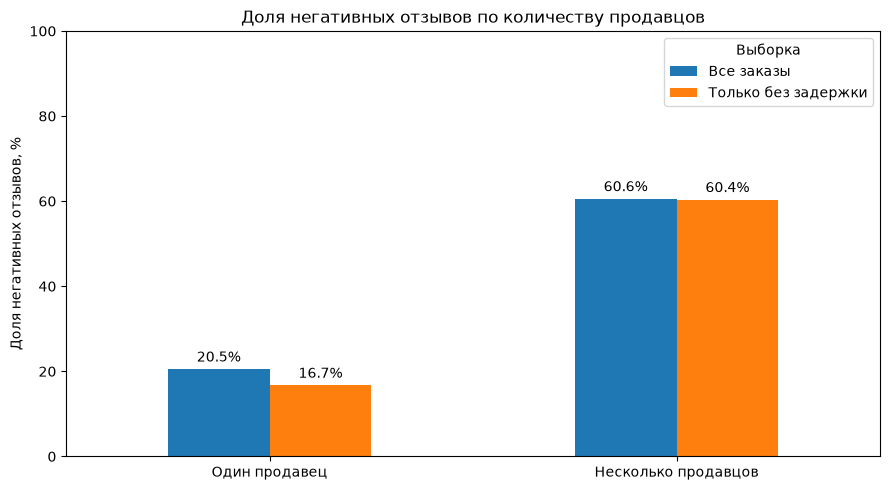

In [15]:
seller_plot_df = pd.DataFrame({
    "Все заказы": {
        "Один продавец": all_orders_result["single_seller_bad_review_rate"],
        "Несколько продавцов": all_orders_result["multi_seller_bad_review_rate"],
    },
    "Только без задержки": {
        "Один продавец": on_time_orders_result["single_seller_bad_review_rate"],
        "Несколько продавцов": on_time_orders_result["multi_seller_bad_review_rate"],
    },
}) * 100

ax = seller_plot_df.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("Доля негативных отзывов по количеству продавцов")
ax.set_xlabel("")
ax.set_ylabel("Доля негативных отзывов, %")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Выборка")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

## 4. Гипотеза 3: длительность доставки среди заказов без задержки

### Бизнес-гипотеза

Даже если заказ доставлен в пределах обещанного срока, более продолжительное ожидание может быть связано с ухудшением клиентской оценки.

Для отделения этого эффекта от нарушения логистического обещания в анализ включаются только заказы, доставленные вовремя или раньше расчётной даты.

Проверяемая гипотеза:

- **H₀:** длительность доставки не связана с клиентской оценкой;
- **H₁:** при увеличении длительности доставки доля негативных отзывов изменяется.

Заказы будут разделены на четыре приблизительно равные группы по продолжительности доставки. Это позволит проверить, наблюдается ли последовательный рост риска негативного отзыва от коротких доставок к более продолжительным.

Результат остаётся наблюдательным: длительность доставки может быть связана с регионом клиента, категорией товара, продавцом и особенностями логистики.

In [16]:
on_time_delivery_df = analysis_df.loc[
    analysis_df["is_delayed"] == 0
].copy()

on_time_delivery_df["delivery_duration_group"] = pd.qcut(
    on_time_delivery_df["delivery_days"],
    q=4,
    duplicates="drop",
)

delivery_duration_summary = (
    on_time_delivery_df.groupby(
        "delivery_duration_group",
        observed=True,
    )
    .agg(
        orders=("order_id", "nunique"),
        minimum_delivery_days=("delivery_days", "min"),
        median_delivery_days=("delivery_days", "median"),
        maximum_delivery_days=("delivery_days", "max"),
        average_review_score=("review_score", "mean"),
        bad_review_rate=("bad_review", "mean"),
    )
)

delivery_duration_summary

,orders,minimum_delivery_days,median_delivery_days,maximum_delivery_days,average_review_score,bad_review_rate
delivery_duration_group,,,,,,
"(-0.001, 6.0]",25874,0.0,4.0,6.0,4.419391,0.137203
"(6.0, 9.0]",20210,7.0,8.0,9.0,4.351781,0.155220
"(9.0, 14.0]",23211,10.0,12.0,14.0,4.278919,0.175132
"(14.0, 70.0]",20148,15.0,19.0,70.0,4.077245,0.236004


### Статистическая проверка

Для проверки гипотезы используются три подхода:

- критерий Краскела — Уоллиса для сравнения распределений `review_score` между четырьмя группами;
- критерий хи-квадрат для проверки связи между группой длительности доставки и негативным отзывом;
- корреляция Спирмена для оценки направления монотонной связи между длительностью доставки и `bad_review`.

Дополнительно сравниваются первая и четвёртая группы, чтобы оценить практический размер эффекта:

- абсолютная разница долей негативных отзывов;
- относительный риск;
- 95%-й доверительный интервал разницы.

In [17]:
from scipy.stats import kruskal, chi2_contingency, spearmanr

delivery_groups = [
    group["review_score"]
    for _, group in on_time_delivery_df.groupby(
        "delivery_duration_group",
        observed=True,
    )
]

kruskal_statistic, kruskal_p_value = kruskal(
    *delivery_groups
)

contingency_table = pd.crosstab(
    on_time_delivery_df["delivery_duration_group"],
    on_time_delivery_df["bad_review"],
)

chi2_statistic, chi2_p_value, _, _ = chi2_contingency(
    contingency_table
)

spearman_correlation, spearman_p_value = spearmanr(
    on_time_delivery_df["delivery_days"],
    on_time_delivery_df["bad_review"],
)

group_categories = (
    on_time_delivery_df["delivery_duration_group"]
    .cat.categories
)

short_delivery = on_time_delivery_df.loc[
    on_time_delivery_df["delivery_duration_group"]
    == group_categories[0]
]

long_delivery = on_time_delivery_df.loc[
    on_time_delivery_df["delivery_duration_group"]
    == group_categories[-1]
]

short_bad_rate = short_delivery["bad_review"].mean()
long_bad_rate = long_delivery["bad_review"].mean()

absolute_effect = long_bad_rate - short_bad_rate
relative_risk = long_bad_rate / short_bad_rate

effect_se = np.sqrt(
    short_bad_rate * (1 - short_bad_rate) / len(short_delivery)
    + long_bad_rate * (1 - long_bad_rate) / len(long_delivery)
)

critical_value = norm.ppf(0.975)

ci_lower = absolute_effect - critical_value * effect_se
ci_upper = absolute_effect + critical_value * effect_se

hypothesis_3_results = pd.Series({
    "short_delivery_orders": len(short_delivery),
    "long_delivery_orders": len(long_delivery),
    "short_delivery_bad_review_rate": short_bad_rate,
    "long_delivery_bad_review_rate": long_bad_rate,
    "absolute_effect": absolute_effect,
    "relative_risk": relative_risk,
    "ci_95_lower": ci_lower,
    "ci_95_upper": ci_upper,
    "kruskal_statistic": kruskal_statistic,
    "kruskal_p_value": kruskal_p_value,
    "chi2_statistic": chi2_statistic,
    "chi2_p_value": chi2_p_value,
    "spearman_correlation": spearman_correlation,
    "spearman_p_value": spearman_p_value,
})

hypothesis_3_results

short_delivery_orders              2.587400e+04
long_delivery_orders               2.014800e+04
short_delivery_bad_review_rate     1.372034e-01
long_delivery_bad_review_rate      2.360036e-01
absolute_effect                    9.880020e-02
relative_risk                      1.720100e+00
ci_95_lower                        9.159237e-02
ci_95_upper                        1.060080e-01
kruskal_statistic                  1.362588e+03
kruskal_p_value                   3.864920e-295
chi2_statistic                     8.346195e+02
chi2_p_value                      1.342396e-180
spearman_correlation               9.781768e-02
spearman_p_value                  5.084866e-189
dtype: float64

### Результаты проверки гипотезы

Среди заказов, доставленных без нарушения обещанного срока, наблюдается последовательный рост доли негативных отзывов по мере увеличения фактической длительности доставки:

- до 6 дней — **13,72%**;
- 7–9 дней — **15,52%**;
- 10–14 дней — **17,51%**;
- 15 дней и более — **23,60%**.

При сравнении крайних групп абсолютная разница составила **9,88 процентного пункта**.

Относительный риск негативного отзыва при длительности доставки 15 дней и более оказался примерно в **1,72 раза выше**, чем при доставке не более чем за 6 дней.

95%-й доверительный интервал абсолютной разницы составляет **[9,16; 10,60] процентного пункта**.

Критерий Краскела — Уоллиса показал статистически значимые различия распределений оценок между группами (`p-value < 0,001`).

Критерий хи-квадрат также подтвердил наличие статистической связи между длительностью доставки и негативным отзывом (`p-value < 0,001`).

Корреляция Спирмена между длительностью доставки и негативным отзывом положительна, но невелика: **ρ = 0,098**. Это означает, что продолжительность доставки связана с клиентским опытом, но сама по себе объясняет лишь небольшую часть различий между отдельными заказами.

### Бизнес-интерпретация

Соблюдение обещанной даты не гарантирует одинаково высокого клиентского опыта.

Клиент может получить заказ формально вовремя, но длительное ожидание всё равно связано с более высокой вероятностью негативной оценки. Следовательно, для управления клиентским опытом важно контролировать не только просрочки, но и абсолютную продолжительность доставки.

Возможные направления улучшения:

- сокращение изначально предлагаемых сроков доставки;
- выделение регионов и продавцов с системно длинным временем исполнения;
- более точная коммуникация о статусе заказа;
- дополнительные уведомления для заказов с длительным ожидаемым сроком;
- отдельный мониторинг заказов, доставка которых продолжается более двух недель.

### Ограничения

Полученная связь не является причинным эффектом.

Долгая доставка может быть связана с удалённостью региона, категорией товара, характеристиками продавца, стоимостью доставки и другими факторами.

Кроме того, несмотря на крайне малые p-value, корреляция на уровне отдельных заказов остаётся слабой. Поэтому вывод следует основывать не только на статистической значимости, но и на размере эффекта между группами.

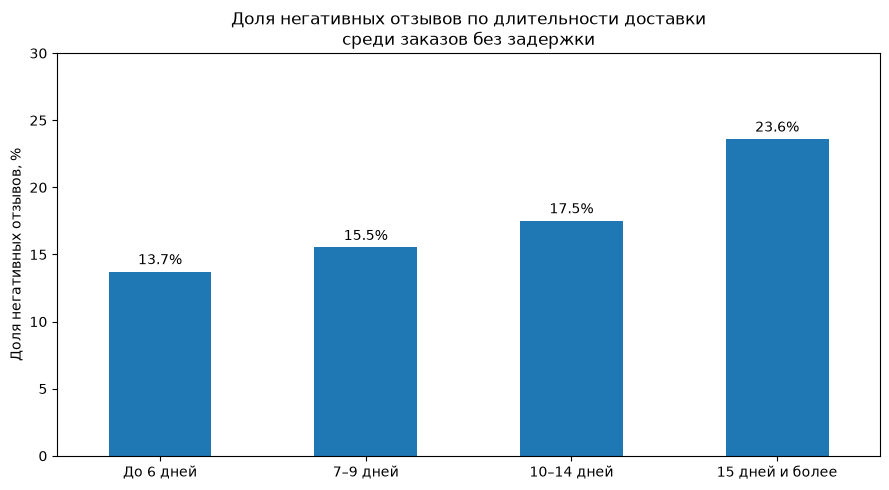

In [18]:
delivery_plot_df = delivery_duration_summary.copy()

delivery_plot_df.index = [
    "До 6 дней",
    "7–9 дней",
    "10–14 дней",
    "15 дней и более",
]

ax = (delivery_plot_df["bad_review_rate"] * 100).plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Доля негативных отзывов по длительности доставки\n"
    "среди заказов без задержки"
)
ax.set_xlabel("")
ax.set_ylabel("Доля негативных отзывов, %")
ax.set_ylim(0, 30)
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

## 5. Симуляция A/B-теста

### Контекст эксперимента

В исходных данных Olist отсутствуют реальные экспериментальные группы и информация о проведённых продуктовых экспериментах. Поэтому далее выполняется синтетическая симуляция A/B-теста, цель которой — продемонстрировать логику планирования эксперимента, расчёта размера выборки и статистической оценки результата.

Рассматривается гипотетическое продуктовое изменение:

> Новая механика проактивного информирования о статусе доставки снижает вероятность негативного отзыва.

Пользователи тестовой группы получают дополнительные уведомления:

- о текущем статусе заказа;
- об изменении ожидаемого срока доставки;
- о разделении заказа на несколько отправлений;
- о возможной задержке.

Контрольная группа получает стандартную коммуникацию без новой механики.

### Дизайн эксперимента

- **Основная метрика:** доля негативных отзывов `bad_review_rate`.
- **Нулевая гипотеза H₀:** доля негативных отзывов одинакова в контрольной и тестовой группах.
- **Альтернативная гипотеза H₁:** доля негативных отзывов различается между контрольной и тестовой группами.
- **Бизнес-ожидание:** новая механика снизит долю негативных отзывов в тестовой группе.
- **Уровень статистической значимости:** 5%.
- **Статистическая мощность:** 80%.
- **MDE:** абсолютное снижение доли негативных отзывов на 2 процентных пункта.
- **Единица рандомизации:** `customer_unique_id`.

Рандомизация проводится на уровне клиента, чтобы один и тот же покупатель не мог одновременно попасть в контрольную и тестовую группы при совершении нескольких заказов.

В реальном эксперименте принадлежность клиента к группе должна сохраняться на протяжении всего периода теста. При анализе заказов также необходимо учитывать, что несколько наблюдений могут относиться к одному клиенту.

### Guardrail-метрики

Помимо основной метрики необходимо контролировать показатели, которые помогут убедиться, что новая механика не ухудшает другие аспекты продукта:

- долю отменённых заказов;
- количество обращений в службу поддержки;
- фактическую длительность доставки;
- долю отключений или отписок от уведомлений;
- расходы на отправку коммуникаций;
- GMV;
- количество заказов.

### Минимально обнаруживаемый эффект

MDE задаётся до запуска эксперимента и отражает минимальный эффект, который одновременно:

- имеет практическую ценность для бизнеса;
- должен быть обнаружен с заданной статистической мощностью;
- используется для расчёта необходимого размера выборки.

В данной симуляции MDE равен абсолютному снижению `bad_review_rate` на 2 процентных пункта.

In [19]:
baseline_bad_review_rate = analysis_df["bad_review"].mean()

alpha = 0.05
power = 0.80
mde_absolute = 0.02

control_rate_assumption = baseline_bad_review_rate
test_rate_assumption = (
    control_rate_assumption - mde_absolute
)

average_rate = (
    control_rate_assumption + test_rate_assumption
) / 2

z_alpha = norm.ppf(1 - alpha / 2)
z_power = norm.ppf(power)

sample_size_per_group = (
    (
        z_alpha
        * np.sqrt(
            2 * average_rate * (1 - average_rate)
        )
        + z_power
        * np.sqrt(
            control_rate_assumption
            * (1 - control_rate_assumption)
            + test_rate_assumption
            * (1 - test_rate_assumption)
        )
    )
    ** 2
    / mde_absolute**2
)

sample_size_per_group = int(
    np.ceil(sample_size_per_group)
)

experiment_design = pd.Series({
    "baseline_bad_review_rate": baseline_bad_review_rate,
    "assumed_test_rate": test_rate_assumption,
    "absolute_mde": mde_absolute,
    "relative_mde": (
        mde_absolute / baseline_bad_review_rate
    ),
    "alpha": alpha,
    "power": power,
    "sample_size_per_group": sample_size_per_group,
    "total_sample_size": sample_size_per_group * 2,
})

experiment_design

baseline_bad_review_rate        0.210605
assumed_test_rate               0.190605
absolute_mde                    0.020000
relative_mde                    0.094965
alpha                           0.050000
power                           0.800000
sample_size_per_group        6293.000000
total_sample_size           12586.000000
dtype: float64

### Расчёт размера выборки

Базовая доля негативных отзывов в аналитической выборке составляет **21,06%**.

Для обнаружения абсолютного снижения показателя на **2 процентных пункта** — с 21,06% до 19,06% — при уровне значимости 5% и статистической мощности 80% требуется:

- **6 293 наблюдения в контрольной группе**;
- **6 293 наблюдения в тестовой группе**;
- **12 586 наблюдений всего**.

Заданный MDE соответствует относительному снижению доли негативных отзывов примерно на **9,5%**.

Расчёт предполагает независимость наблюдений. В реальном эксперименте при рандомизации по `customer_unique_id` необходимо учитывать возможную зависимость между несколькими заказами одного клиента. В данных Olist повторные покупки редки, поэтому для учебной симуляции используется упрощённое предположение о независимых наблюдениях.

In [20]:
random_generator = np.random.default_rng(42)

control_outcomes = random_generator.binomial(
    n=1,
    p=control_rate_assumption,
    size=sample_size_per_group,
)

test_outcomes = random_generator.binomial(
    n=1,
    p=test_rate_assumption,
    size=sample_size_per_group,
)

control_bad_review_rate = control_outcomes.mean()
test_bad_review_rate = test_outcomes.mean()

absolute_reduction = (
    control_bad_review_rate
    - test_bad_review_rate
)

relative_reduction = (
    absolute_reduction
    / control_bad_review_rate
)

pooled_rate = (
    control_outcomes.sum()
    + test_outcomes.sum()
) / (
    len(control_outcomes)
    + len(test_outcomes)
)

pooled_standard_error = np.sqrt(
    pooled_rate
    * (1 - pooled_rate)
    * (
        1 / len(control_outcomes)
        + 1 / len(test_outcomes)
    )
)

z_statistic = (
    absolute_reduction
    / pooled_standard_error
)

p_value = 2 * norm.sf(
    abs(z_statistic)
)

effect_standard_error = np.sqrt(
    control_bad_review_rate
    * (1 - control_bad_review_rate)
    / len(control_outcomes)
    + test_bad_review_rate
    * (1 - test_bad_review_rate)
    / len(test_outcomes)
)

critical_value = norm.ppf(0.975)

ci_lower = (
    absolute_reduction
    - critical_value * effect_standard_error
)

ci_upper = (
    absolute_reduction
    + critical_value * effect_standard_error
)

ab_test_results = pd.Series({
    "control_size": len(control_outcomes),
    "test_size": len(test_outcomes),
    "control_bad_review_rate": control_bad_review_rate,
    "test_bad_review_rate": test_bad_review_rate,
    "absolute_reduction": absolute_reduction,
    "relative_reduction": relative_reduction,
    "z_statistic": z_statistic,
    "p_value": p_value,
    "ci_95_lower": ci_lower,
    "ci_95_upper": ci_upper,
})

ab_test_results

control_size               6293.000000
test_size                  6293.000000
control_bad_review_rate       0.206261
test_bad_review_rate          0.185444
absolute_reduction            0.020817
relative_reduction            0.100924
z_statistic                   2.942354
p_value                       0.003257
ci_95_lower                   0.006955
ci_95_upper                   0.034679
dtype: float64

### Результаты симуляции A/B-теста

В синтетическом эксперименте каждая группа содержала по **6 293 наблюдения**.

Полученные значения основной метрики:

- контрольная группа — **20,63%** негативных отзывов;
- тестовая группа — **18,54%** негативных отзывов.

Наблюдаемое абсолютное снижение `bad_review_rate` составило **2,08 процентного пункта**, а относительное снижение — около **10,09%**.

Двусторонний z-тест разности долей дал `p-value = 0,0033`. При уровне значимости 5% нулевая гипотеза об отсутствии различий между группами отвергается.

95%-й доверительный интервал абсолютного снижения составляет **[0,70; 3,47] процентного пункта**. Поскольку интервал не включает ноль, результат статистически значим.

### Бизнес-интерпретация

В рамках данной симуляции новая механика информирования достигла ожидаемого результата: доля негативных отзывов в тестовой группе оказалась ниже, чем в контрольной.

Наблюдаемое снижение примерно соответствует заложенному MDE в 2 процентных пункта. При подтверждении такого эффекта в реальном эксперименте продуктовая команда могла бы рассматривать масштабирование механики, однако только после проверки guardrail-метрик и стоимости коммуникаций.

Для принятия решения необходимо оценивать не только `p-value`, но и:

- величину абсолютного эффекта;
- доверительный интервал;
- стоимость внедрения;
- влияние на обращения в поддержку;
- отписки от уведомлений;
- возможное влияние на GMV и повторные покупки.

### Ограничения симуляции

Полученный результат не является доказательством эффективности реальной механики.

Данные групп были сгенерированы искусственно с заранее заданными вероятностями:

- control — около 21,06%;
- test — около 19,06%.

Следовательно, симуляция демонстрирует корректную процедуру анализа A/B-теста, но не оценивает реальный продуктовый эффект.

Кроме того, отдельный запуск симуляции зависит от случайной генерации данных. Даже при наличии истинного эффекта эксперимент с мощностью 80% не обязан показывать статистическую значимость в каждом запуске.

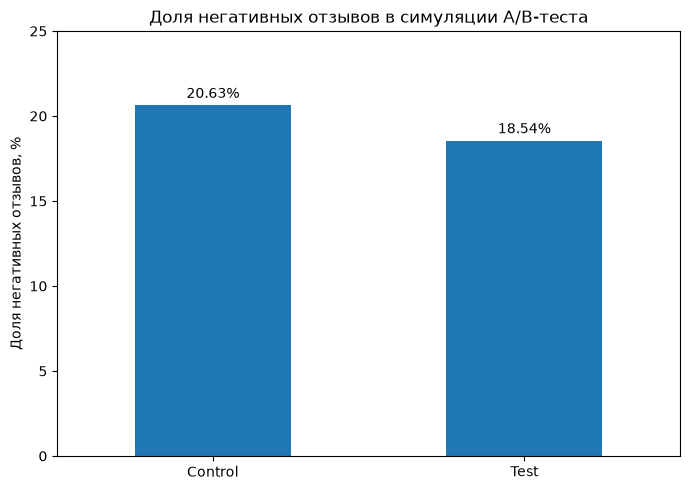

In [21]:
ab_plot_df = pd.Series({
    "Control": control_bad_review_rate * 100,
    "Test": test_bad_review_rate * 100,
})

ax = ab_plot_df.plot(
    kind="bar",
    figsize=(7, 5),
)

ax.set_title("Доля негативных отзывов в симуляции A/B-теста")
ax.set_xlabel("")
ax.set_ylabel("Доля негативных отзывов, %")
ax.set_ylim(0, 25)
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

In [22]:
ab_plot_df = pd.Series({
    "Контроль": control_bad_review_rate * 100,
    "Тест": test_bad_review_rate * 100,
})

### Проверка статистической мощности

Результат одного A/B-теста зависит от случайного состава групп. Даже при наличии реального эффекта отдельный эксперимент может не показать статистическую значимость.

Чтобы проверить рассчитанную мощность, проводится серия синтетических экспериментов с одинаковыми параметрами:

- базовый `bad_review_rate` — 21,06%;
- ожидаемый показатель в тестовой группе — 19,06%;
- размер каждой группы — 6 293 наблюдения;
- уровень значимости — 5%.

Эмпирическая мощность определяется как доля симуляций, в которых нулевая гипотеза была отвергнута.

In [23]:
n_simulations = 2000
simulation_generator = np.random.default_rng(2026)

control_bad_counts = simulation_generator.binomial(
    n=sample_size_per_group,
    p=control_rate_assumption,
    size=n_simulations,
)

test_bad_counts = simulation_generator.binomial(
    n=sample_size_per_group,
    p=test_rate_assumption,
    size=n_simulations,
)

control_rates = (
    control_bad_counts / sample_size_per_group
)

test_rates = (
    test_bad_counts / sample_size_per_group
)

simulated_effects = control_rates - test_rates

pooled_rates = (
    control_bad_counts + test_bad_counts
) / (
    sample_size_per_group * 2
)

simulated_standard_errors = np.sqrt(
    pooled_rates
    * (1 - pooled_rates)
    * (2 / sample_size_per_group)
)

simulated_z_statistics = (
    simulated_effects / simulated_standard_errors
)

simulated_p_values = 2 * norm.sf(
    np.abs(simulated_z_statistics)
)

empirical_power = (
    simulated_p_values < alpha
).mean()

power_simulation_results = pd.Series({
    "number_of_simulations": n_simulations,
    "significant_experiments": (
        simulated_p_values < alpha
    ).sum(),
    "empirical_power": empirical_power,
    "target_power": power,
    "average_observed_effect": simulated_effects.mean(),
    "effect_standard_deviation": simulated_effects.std(),
})

power_simulation_results

number_of_simulations        2000.000000
significant_experiments      1631.000000
empirical_power                 0.815500
target_power                    0.800000
average_observed_effect         0.020327
effect_standard_deviation       0.007154
dtype: float64

### Результаты проверки статистической мощности

Было проведено 2 000 независимых симуляций A/B-теста с рассчитанным размером выборки — по 6 293 наблюдения в каждой группе.

Статистически значимый результат был получен в **1 631 эксперименте**, что соответствует эмпирической мощности **81,55%**.

Это близко к заданной при планировании мощности 80% и подтверждает, что рассчитанный размер выборки позволяет обнаруживать абсолютное снижение `bad_review_rate` на 2 процентных пункта примерно в четырёх экспериментах из пяти.

Средний наблюдаемый эффект по всем симуляциям составил **2,03 процентного пункта**, что практически совпадает с заложенным истинным эффектом в 2 процентных пункта.

Стандартное отклонение наблюдаемого эффекта составило около **0,72 процентного пункта**. Это показывает, что результаты отдельных экспериментов могут заметно отличаться из-за случайности выборки, даже если истинный эффект остаётся постоянным.

### Методологический вывод

Статистическая мощность не означает вероятность того, что результат конкретного уже проведённого теста является истинным.

Мощность показывает вероятность обнаружить заданный эффект при условии, что этот эффект действительно существует.

При мощности 80% примерно 20% корректно проведённых экспериментов могут не показать статистическую значимость, несмотря на наличие реального эффекта.

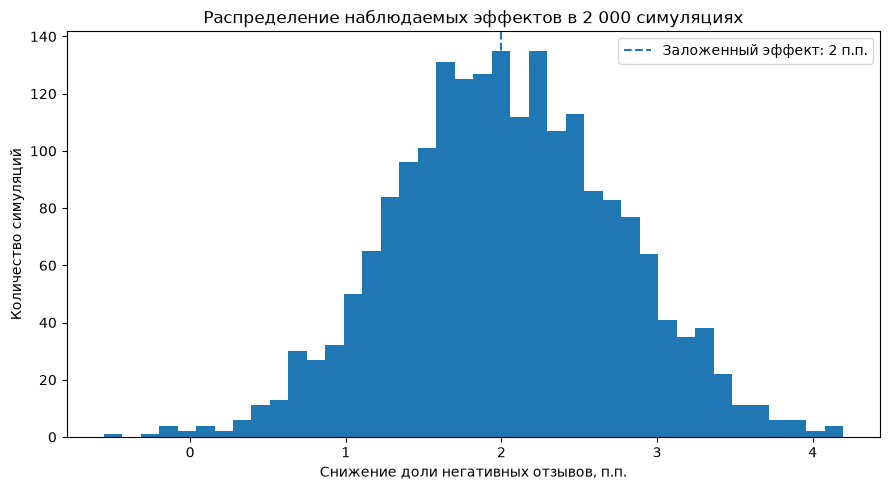

In [24]:
ax = pd.Series(
    simulated_effects * 100
).plot(
    kind="hist",
    bins=40,
    figsize=(9, 5),
)

ax.axvline(
    mde_absolute * 100,
    linestyle="--",
    label="Заложенный эффект: 2 п.п.",
)

ax.set_title("Распределение наблюдаемых эффектов в 2 000 симуляциях")
ax.set_xlabel("Снижение доли негативных отзывов, п.п.")
ax.set_ylabel("Количество симуляций")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Итоговые выводы

В ноутбуке были проверены три наблюдательные продуктовые гипотезы и проведена синтетическая симуляция A/B-теста.

### Наблюдательные гипотезы

#### 1. Задержка доставки

Задержанные заказы существенно чаще связаны с негативным клиентским опытом:

- `bad_review_rate` без задержки — **17,34%**;
- `bad_review_rate` при задержке — **73,25%**;
- абсолютная разница — **55,91 процентного пункта**;
- относительный риск — около **4,22**.

Средняя оценка задержанных заказов оказалась ниже примерно на **2,02 балла**.

Задержка относительно обещанной даты является одним из наиболее сильных операционных сигналов риска негативного отзыва в данных Olist.

#### 2. Заказы нескольких продавцов

У заказов, включающих товары нескольких продавцов, доля негативных отзывов составила **60,59%**, тогда как у заказов одного продавца — **20,53%**.

Абсолютная разница равна **40,05 процентного пункта**, а относительный риск — около **2,95**.

Связь сохранилась и после исключения задержанных заказов:

- один продавец — **16,73%**;
- несколько продавцов — **60,37%**.

Это позволяет предположить, что повышенный риск multi-seller заказов связан не только с задержками, но и со сложностью исполнения: несколькими отправлениями, частичной доставкой или координацией разных продавцов.

#### 3. Абсолютная длительность доставки

Даже среди заказов, доставленных в пределах обещанного срока, доля негативных отзывов увеличивалась по мере роста фактического времени ожидания:

- до 6 дней — **13,72%**;
- 7–9 дней — **15,52%**;
- 10–14 дней — **17,51%**;
- 15 дней и более — **23,60%**.

Между первой и последней группами абсолютная разница составила **9,88 процентного пункта**, а относительный риск — около **1,72**.

Следовательно, для клиентского опыта важно контролировать не только соблюдение обещанной даты, но и общую продолжительность доставки.

### Ограничения наблюдательного анализа

Все выявленные зависимости являются наблюдательными и не доказывают причинно-следственную связь.

На клиентскую оценку также могут влиять:

- категория товара;
- регион клиента;
- характеристики продавца;
- количество товарных позиций;
- стоимость доставки;
- качество товара;
- коммуникация со службой поддержки;
- проблемы с отдельными частями заказа.

Статистическая значимость сама по себе не означает большой бизнес-эффект. Поэтому при интерпретации учитывались абсолютная разница, относительный риск и доверительные интервалы.

### Симуляция A/B-теста

Была смоделирована новая механика проактивного информирования клиента о статусе доставки.

При базовой доле негативных отзывов **21,06%** и MDE в **2 процентных пункта** рассчитанный минимальный размер выборки составил:

- **6 293 наблюдения на группу**;
- **12 586 наблюдений всего**.

В одном воспроизводимом запуске симуляции были получены следующие результаты:

- control — **20,63%** негативных отзывов;
- test — **18,54%**;
- абсолютное снижение — **2,08 процентного пункта**;
- относительное снижение — **10,09%**;
- `p-value = 0,0033`;
- 95%-й доверительный интервал — **[0,70; 3,47] процентного пункта**.

В рамках этой симуляции нулевая гипотеза была отвергнута.

Проверка на 2 000 повторных симуляциях показала эмпирическую мощность **81,55%**, что близко к запланированным 80%.

Это подтверждает корректность расчёта размера выборки и показывает, что даже при существующем эффекте отдельный эксперимент может не дать статистически значимого результата.

### Бизнес-рекомендации

На основании наблюдательного анализа можно сформулировать следующие направления для продуктовой команды:

- приоритизировать заказы, приближающиеся к обещанной дате доставки;
- проактивно информировать клиентов о возможных задержках;
- выделить multi-seller заказы в отдельный риск-сегмент;
- улучшить отображение статуса отдельных отправлений внутри одного заказа;
- контролировать не только просрочки, но и заказы с длительностью доставки более двух недель;
- проверять эффективность коммуникационных изменений через контролируемый A/B-тест.

Перед масштабированием новой механики необходимо оценить не только основную метрику, но и guardrail-показатели: обращения в поддержку, отписки от уведомлений, стоимость коммуникаций, отмены заказов и GMV.

## Главный вывод

Клиентский опыт в Olist тесно связан с качеством исполнения логистического обещания и сложностью заказа.

Наблюдательный анализ помогает определить проблемные сегменты и сформулировать гипотезы, но причинный эффект продуктового изменения должен проверяться только через заранее спроектированный рандомизированный эксперимент.